In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv('../data/train.csv')
features = pd.read_csv('../data/features.csv')
stores = pd.read_csv('../data/stores.csv')

df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'])

print(df.shape)
df.head()

(421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
MarkDown2,310322,73.61
MarkDown4,286603,67.98
MarkDown3,284479,67.48
MarkDown1,270889,64.26
MarkDown5,270138,64.08
Store,0,0.00
Date,0,0.00
Dept,0,0.00
Fuel_Price,0,0.00
Temperature,0,0.00


In [5]:
df.groupby('Type')['Weekly_Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
A,215478.0,20099.568043,26423.457227,-4988.94,3315.090,10105.17,26357.18,474330.10
B,163495.0,12237.075977,17203.668989,-3924.00,1927.055,6187.87,15353.74,693099.36
C,42597.0,9519.532538,15985.351612,-379.00,131.990,1149.67,12695.01,112152.35


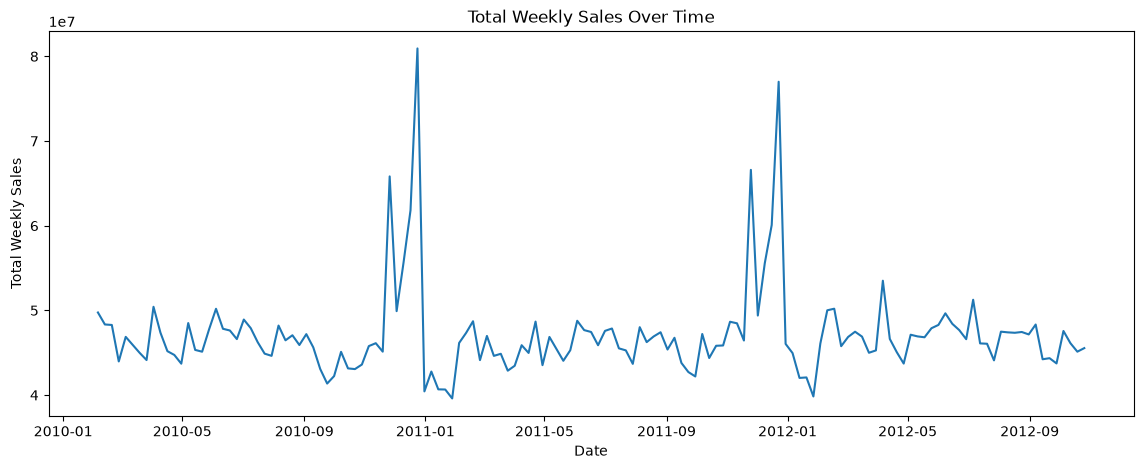

In [6]:
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(14, 5))
plt.plot(weekly_total.index, weekly_total.values)
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.show()

In [8]:
negative_sales = df[df['Weekly_Sales'] < 0]
print(f"Rows with negative sales: {len(negative_sales)} ({len(negative_sales)/len(df)*100:.3f}%)")
negative_sales['Weekly_Sales'].describe()

Rows with negative sales: 1285 (0.305%)


count    1285.000000
mean      -68.608218
std       231.664245
min     -4988.940000
25%       -41.000000
50%       -13.200000
75%        -4.940000
max        -0.020000
Name: Weekly_Sales, dtype: float64

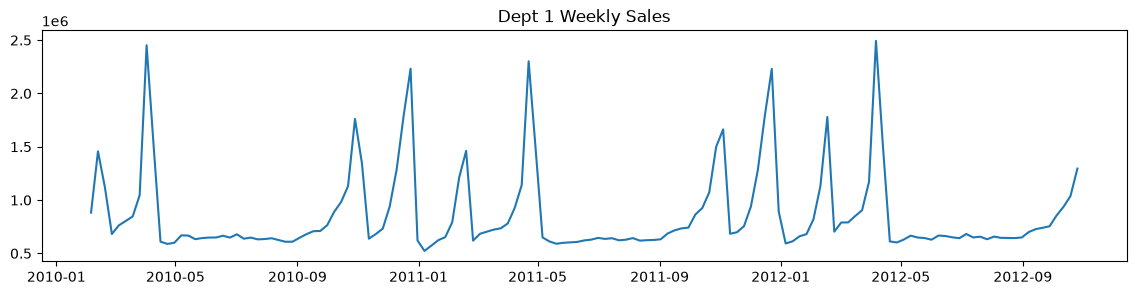

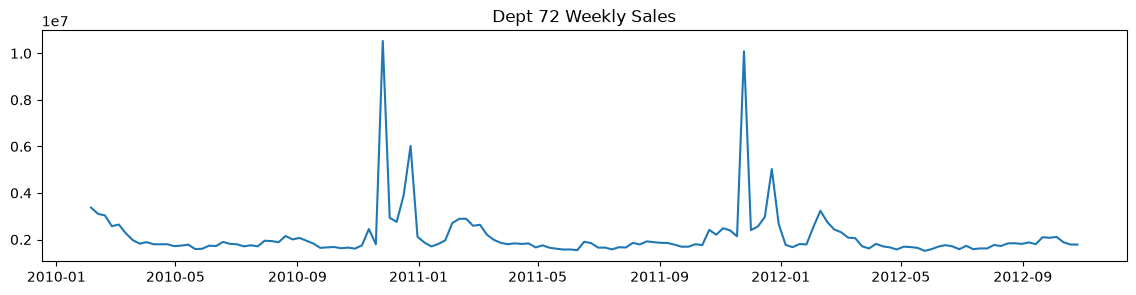

In [9]:
for dept in [1, 72]:  # 72 is a good example of a highly seasonal dept
    dept_sales = df[df['Dept'] == dept].groupby('Date')['Weekly_Sales'].sum()
    plt.figure(figsize=(14, 3))
    plt.plot(dept_sales.index, dept_sales.values)
    plt.title(f'Dept {dept} Weekly Sales')
    plt.show()

In [10]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df['YearMonth'] = df['Date'].dt.to_period('M')
df.groupby('YearMonth')[markdown_cols].apply(lambda x: x.isnull().mean())

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
YearMonth,,,,,
2010-02,1.000000,1.000000,1.000000,1.000000,1.000000
2010-03,1.000000,1.000000,1.000000,1.000000,1.000000
2010-04,1.000000,1.000000,1.000000,1.000000,1.000000
2010-05,1.000000,1.000000,1.000000,1.000000,1.000000
2010-06,1.000000,1.000000,1.000000,1.000000,1.000000
2010-07,1.000000,1.000000,1.000000,1.000000,1.000000
2010-08,1.000000,1.000000,1.000000,1.000000,1.000000
2010-09,1.000000,1.000000,1.000000,1.000000,1.000000
2010-10,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
stores.groupby('Type')['Size'].describe()

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
A,22.0,177247.727273,49392.621098,39690.0,155840.75,202406.0,203819.0,219622.0
B,17.0,101190.705882,32371.137916,34875.0,93188.00,114533.0,123737.0,140167.0
C,6.0,40541.666667,1304.145033,39690.0,39745.00,39910.0,40774.0,42988.0
